In [1]:
!pip install langchain langchain-community sentence-transformers

!pip install qdrant-client==1.7.0
# runs temporary in-memory DB

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0rc2
    Uninstalling packaging-26.0rc2:
      Successfully uninstalled packaging-26.0rc2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.

In [2]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("/kaggle/input/carmdfile/VICTORIS-99011M71U00-74W-pages-2.md", encoding="utf-8")
docs = loader.load()
print("Done")


Done


In [3]:
from langchain.text_splitter import MarkdownHeaderTextSplitter

headers = [
    ("#", "h1"),

]

splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers)

md_docs = splitter.split_text(docs[0].page_content)
md_docs[2]



Document(metadata={'h1': 'Driver’s Seat Floor Floor Mats'}, page_content='![](images/929c8e43a4367cce6c1bad9078e295a7790d05c99a28b0fe7fde5d899b189c51.jpg)\n55T020010  \nTo prevent the driver’s side floor mat from sliding forward and possibly interfering with the operation of the pedals, Maruti Suzuki genuine floor mats are recommended.  \nWhenever you put the driver’s side floor mat back in the vehicle after it has been removed, hook the floor mat grommets to the fasteners and position the floor mat properly in the footwell.  \nWhen you replace the floor mats in your vehicle with a different type such as allweather floor mats, we highly recommend to use Maruti Suzuki genuine floor mats for proper fitting.  \n![](images/362a4cf80923151d7ac5750d4a3e3614ea431bde4a046b2742d201c3f54c1cf1.jpg)  \nFailure to take the following precautions may result in the driver’s side floor mat interfering with the pedals and causing a loss of vehicle control or an accident.  \n• Check that the floor mat gr

In [4]:
# Use only header-based chunking (no further recursive splitting)
# This keeps complete sections together, preserving context and images
final_chunks = md_docs
print(f"Total chunks (header-based): {len(final_chunks)}")


Total chunks (header-based): 1034


In [5]:
from langchain_core.documents import Document
import re

texts_for_embedding = []

# Process chunks - CONVERT image markdown to descriptive text
for chunk in final_chunks:
    h1 = chunk.metadata.get('h1') or ""
    h2 = chunk.metadata.get('h2') or ""
    g3 = chunk.metadata.get('g3') or ""

    header_context = " ".join(filter(None, [
        f"{h1}" if h1 else "",
        f"{h2}" if h2 else "",
        f"{g3}" if g3 else ""
    ]))
    
    # Clean text but PRESERVE image metadata differently
    chunk.page_content = re.sub(r'\b[A-Z0-9]{6,}\b', ' ', chunk.page_content)
    chunk.page_content = re.sub(r'\s+', ' ', chunk.page_content)
    chunk.page_content = chunk.page_content.strip()
    
    # CONVERT markdown image syntax to descriptive text
    # Replace ![](path) with [Image reference]
    # This makes images semantic rather than syntactic
    chunk.page_content = re.sub(r'!\[\]\((.*?)\)', r'[Image reference: \1]', chunk.page_content)
    
    # Create enriched text for embedding
    text_for_embedding = f"{header_context} {chunk.page_content}"
    
    doc = Document(page_content=text_for_embedding, metadata=chunk.metadata)
    texts_for_embedding.append(doc)
 
print(f"Processed {len(texts_for_embedding)} chunks with images converted to semantic references")


Processed 1034 chunks with images converted to semantic references


image metadata

In [6]:
# Images are now embedded in chunk metadata
# No separate image extraction needed
print("✅ Images are now integrated into chunk metadata")


✅ Images are now integrated into chunk metadata


In [7]:
pip install rank-bm25


Note: you may need to restart the kernel to use updated packages.


In [8]:
# Image retrieval is now handled through chunk metadata
# The hybrid retriever will bring back chunks that have images
print("✅ Images will be retrieved as part of chunk metadata")


✅ Images will be retrieved as part of chunk metadata


In [9]:
def extract_images_from_text(text):
    """Extract image paths from semantic format [Image reference: path]"""
    pattern = r'\[Image reference: (.*?)\]'
    images = re.findall(pattern, text)
    return images

def display_answer_with_images_inline(answer_text, base_image_path="/kaggle/input/carimages/"):
    """Display answer and show images inline where they're referenced"""
    import os
    from IPython.display import Image, display
    
    # First, display the raw answer as-is
    print("RAW ANSWER:")
    print("="*70)
    print(answer_text)
    print("\n" + "="*70)
    print("ANSWER WITH IMAGES:")
    print("="*70 + "\n")
    
    # Pattern to match [Image reference: path]
    pattern = r'\[Image reference: (.*?)\]'
    
    # Split the text by image references, keeping the images
    parts = re.split(f'({pattern})', answer_text)
    
    seen_images = set()
    
    for part in parts:
        if not part:  # Skip empty parts
            continue
            
        # Check if this part is an image reference
        img_match = re.match(pattern, part)
        
        if img_match:
            # This is an image reference
            img_path = img_match.group(1)
            
            if img_path not in seen_images:
                seen_images.add(img_path)
                full_path = os.path.join(base_image_path, img_path)
                
                print(f"\n[Image: {img_path}]")
                try:
                    if os.path.exists(full_path):
                        display(Image(filename=full_path))
                    else:
                        print(f"⚠️ Image not found at: {full_path}")
                except Exception as e:
                    print(f"⚠️ Could not display: {e}")
                print()
        else:
            # Regular text - print it as-is
            if part.strip():
                print(part, end='')


In [10]:
# Remove visual duplicates is no longer needed since images come from chunks
# Each image in a chunk is unique to that context
print("✅ Image deduplication handled through chunk context")


✅ Image deduplication handled through chunk context


llama-index

In [11]:
from langchain_community.embeddings import HuggingFaceEmbeddings

class BGEEmbeddings(HuggingFaceEmbeddings):
    def __init__(self):
        super().__init__(
            model_name="BAAI/bge-base-en-v1.5",
            model_kwargs={
                "device": "cuda",
                   # saves memory
            },
            encode_kwargs={
                "normalize_embeddings": True,
                "batch_size": 8
            }
        )

    def embed_documents(self, texts):
        # No prefix for documents
        return super().embed_documents(texts)

    def embed_query(self, text):
        # BGE requires query prefix
        return super().embed_query("query: " + text)



In [12]:
embeddings = BGEEmbeddings()




2026-02-11 17:45:39.272719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770831939.647743      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770831939.760118      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770831940.712075      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770831940.712113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770831940.712115      55 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM-PHI-3 MINI 

In [13]:
from langchain_community.vectorstores import Qdrant
from langchain.docstore.document import Document


vectorstore = Qdrant.from_documents(
    texts_for_embedding,                # your Document chunks
    embeddings,
    path="/kaggle/working/qdrant_storage10",
    collection_name="markdown_rag10",
    
)


BM25

In [14]:
from rank_bm25 import BM25Okapi

# Suppose this already exists in your pipeline
docs = [bm25chunk.page_content for bm25chunk in  texts_for_embedding]
metadatas=[bm25chunk.metadata for bm25chunk in  texts_for_embedding]# list of strings

# Tokenize (simple whitespace tokenizer works fine to start)
tokenized_corpus = [doc.lower().split() for doc in docs]

bm25 = BM25Okapi(tokenized_corpus)



In [15]:
dense_retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 15,
        "fetch_k": 30
    }
)
print("done")


done


hybrid retriver

In [16]:
from typing import List
import numpy as np
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from pydantic import Field


class HybridRetriever(BaseRetriever):
    dense_retriever: any = Field(...)
    bm25: any = Field(...)
    texts: List[str] = Field(...)
    metadatas: List[dict] = Field(...)
    k_sparse: int = 10
    k_final: int = 5  # LIMIT final results to top 5 most relevant

    def _get_relevant_documents(self, query: str) -> List[Document]:
        # ----- Dense retrieval (Qdrant MMR) -----
        dense_docs = self.dense_retriever.get_relevant_documents(query)

        # ----- BM25 sparse retrieval -----
        tokenized_query = query.lower().split()
        scores = self.bm25.get_scores(tokenized_query)
        top_idx = np.argsort(scores)[::-1][:self.k_sparse]

        sparse_docs = [
            Document(page_content=self.texts[i], metadata=self.metadatas[i])
            for i in top_idx
        ]

        # ----- Merge and deduplicate -----
        combined = dense_docs + sparse_docs
        unique_docs = {doc.page_content: doc for doc in combined}
        
        # ----- LIMIT to top 5 most relevant -----
        result = list(unique_docs.values())[:self.k_final]

        return result


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:648: ArbitraryTypeWarning: <built-in function any> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warnings.warn(


In [17]:
hybrid_retriever = HybridRetriever(
    dense_retriever=dense_retriever,
    bm25=bm25,
    texts=docs,
    metadatas=metadatas,
    k_sparse=10,
    k_final=5  # Limit to top 5 most relevant documents
)


In [26]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_id = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=2000,
    do_sample=False,
    temperature=0.1,
    return_full_text=False,
    eos_token_id=tokenizer.eos_token_id
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


In [27]:
from langchain.llms import HuggingFacePipeline

llm = HuggingFacePipeline(pipeline=pipe)


In [28]:
from langchain_core.prompts import PromptTemplate

# Explicit prompt to include image references found in context
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""Answer the question using ONLY the manual content provided below.

When the manual content contains [Image reference: ...] for a step, include that image reference in your answer right after that step.

Manual Content:
{context}

Question: {question}

Answer (numbered steps, include image references when present in context):"""
)

print("done")


done


In [34]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

# Create a custom chain that returns both answer and source documents
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def truncate_at_question(text):
    """Stop output at first 'Question:' to prevent extra Q&A generation"""
    if "Question:" in text:
        return text.split("Question:")[0].strip()
    return text.strip()

# Chain with source documents
qa_chain = (
    RunnableParallel(context=hybrid_retriever | format_docs, question=RunnablePassthrough())
    | prompt
    | llm
    | StrOutputParser()
    | truncate_at_question
)

# Store retriever for later use in ask function
stored_retriever = hybrid_retriever


In [35]:
def ask(query):
    """
    Ask a question and get answer with images displayed inline where they're referenced
    """
    # Display results
    print(f"\n{'='*70}")
    print(f"QUERY: {query}")
    print(f"{'='*70}\n")
    
    # Get relevant documents (context) from the hybrid retriever
    relevant_docs = stored_retriever.get_relevant_documents(query)
    
    # Display the context being passed to LLM
    print("CONTEXT PASSED TO LLM:")
    print("="*70)
    for i, doc in enumerate(relevant_docs, 1):
        print(f"\n--- Document {i} ---")
        print(f"Metadata: {doc.metadata}")
        print(f"Content Preview: {doc.page_content[:500]}...")  # Show first 500 chars
    print("\n" + "="*70 + "\n")
    
    # Get LLM response - images should be preserved by the LLM
    answer = qa_chain.invoke(query)
    
    # Display answer with images shown inline where they're referenced
    display_answer_with_images_inline(answer)

In [36]:
# Images are preserved in chunks and passed to LLM
# LLM is instructed to keep image references in the answer
# Images are displayed exactly where the LLM puts them in the answer
print("✅ Images are embedded in context, preserved by LLM, and displayed where referenced")


✅ Images are embedded in context, preserved by LLM, and displayed where referenced


In [37]:
def ask_with_image_extraction(query):
    """
    Ask a question - let LLM decide where to put images
    """
    print(f"\n{'='*70}")
    print(f"QUERY: {query}")
    print(f"{'='*70}\n")
    
    # Get relevant documents
    relevant_docs = stored_retriever.get_relevant_documents(query)
    
    print("CONTEXT PASSED TO LLM:")
    print("="*70)
    for i, doc in enumerate(relevant_docs, 1):
        print(f"\n--- Document {i}: {doc.metadata.get('h1', 'Unknown')} ---")
        print(f"Content Preview: {doc.page_content[:300]}...")
    print("\n" + "="*70 + "\n")
    
    # Get LLM response
    answer = qa_chain.invoke(query)
    
    # Display answer as-is without any post-processing
    display_answer_with_images_inline(answer)




QUERY: How to change the tyres?

CONTEXT PASSED TO LLM:

--- Document 1: Changing Wheels ---
Content Preview: Changing Wheels [Image reference: images/211b76f967cef37e7539a6fb8d70fe2d9c578b416aa068b4f1aea07f3a0197e6.jpg] Never change a wheel in traffic lane. Always move the vehicle off the road on level, hard ground away from traffic for changing a wheel. For any further assistance contact your nearest Maru...

--- Document 2: Tyre Rotation 4-tyre rotation ---
Content Preview: Tyre Rotation 4-tyre rotation [Image reference: images/da1f256a4d3270790ac95191efbe27c9d039cf70eeee26853823ca81f784a732.jpg]...

--- Document 3: To Check the Current Tyre Inflation Pressure (For instrument cluster - Type A) ---
Content Preview: To Check the Current Tyre Inflation Pressure (For instrument cluster - Type A) You can check the current tyre pressure on the information display. [Image reference: images/178792f2b760fdd14ce2c0c721e10cf48377f183c10df34a9f0672975e7289ff.jpg] 1) When the ignition mode is O

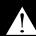


images/211b76f967cef37e7539a6fb8d70fe2d9c578b416aa068b4f1aea07f3a0197e6.jpg
2) Shift into “P” (Park) for an automatic transmission or e-CVT, or into “R” (Reverse) for a manual transmission vehicle when you jack up the vehicle. 
[Image: images/3fcd319d5ec7a5e9f6fa1b2d9cf4caeb7a7eed6faae6861239386ba53f4a179a.jpg]


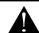


images/3fcd319d5ec7a5e9f6fa1b2d9cf4caeb7a7eed6faae6861239386ba53f4a179a.jpg
3) Jack up the vehicle (follow the jacking instructions in this section). 
[Image: images/eb91fa2d4d8d165c9a2c6609514f6d4ee175402db6f619680a5d28d9829edcdf.jpg]


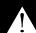


images/eb91fa2d4d8d165c9a2c6609514f6d4ee175402db6f619680a5d28d9829edcdf.jpg
4) Remove the wheel nuts and wheel. 
[Image: images/ff40c168d79544f7e27d99a2096b8c48bcc2209a2e4ec4df07d3474eb5eb9f64.jpg]


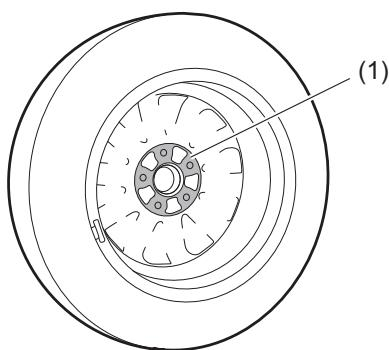


images/ff40c168d79544f7e27d99a2096b8c48bcc2209a2e4ec4df07d3474eb5eb9f64.jpg
5) Clean any mud or dirt off from the surface of the wheel (1), hub (2), thread part (3) and surface of the wheel nuts (4) with a clean cloth. 
[Image: images/9778e52ad475ab84368c5c1d3623cba4c21f16cdfab9661c725cfd2ad615a6ec.jpg]


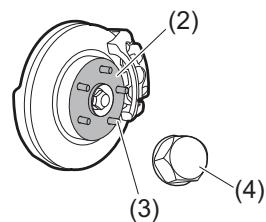


images/9778e52ad475ab84368c5c1d3623cba4c21f16cdfab9661c725cfd2ad615a6ec.jpg
6) Install the new wheel and replace the wheel nuts with their cone shaped end facing the wheel. Tighten each nut snugly by hand until the wheel is securely seated on the hub. 
[Image: images/70ccdb2263af6181a00ef92f2dcb141fc9a3c353656f2dfae38264b35c7cefc1.jpg]


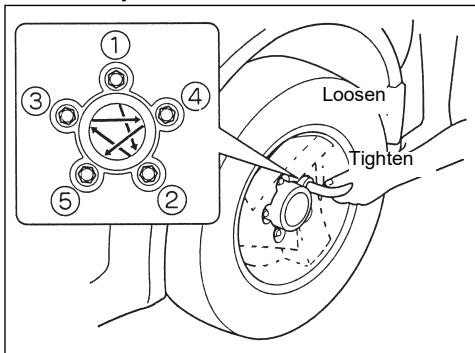


images/70ccdb2263af6181a00ef92f2dcb141fc9a3c353656f2dfae38264b35c7cefc1.jpg

'None'

In [38]:
(str(ask_with_image_extraction("How to change the tyres?")))
